## Setup

In [1]:
import Pkg
Pkg.activate(@__DIR__)
Pkg.status()

  Activating project at `~/Documents/Carnegie-Mellon/Chatterjee Group/Programming/WignerMolecule.jl/analysis`


Status `~/Documents/Carnegie-Mellon/Chatterjee Group/Programming/WignerMolecule.jl/analysis/Project.toml`
  [13f3f980] CairoMakie v0.15.11
⌃ [780c37f4] Carlo v0.2.6
  [074ae576] CarloAnalysis v1.0.0-DEV `https://github.com/PatXue/CarloAnalysis.jl#main`
  [a93c6f00] DataFrames v1.8.2
  [7a1cc6ca] FFTW v1.10.0
  [f67ccb44] HDF5 v0.17.3
  [033835bb] JLD2 v0.6.4
  [ebeed567] PeriodicArrays v0.1.0 `https://github.com/PatXue/PeriodicArrays.jl#main`
  [90137ffa] StaticArrays v1.9.18
Info Packages marked with ⌃ have new versions available and may be upgradable.


In [2]:
using CairoMakie
using Carlo.ResultTools
using CarloAnalysis
using DataFrames
using FFTW
using HDF5
using JLD2
using LinearAlgebra
using PeriodicArrays
using StaticArrays

In [3]:
function generate_spins(jobname, task_no)
    fig = Figure(size=(400, 400))

    task_str = lpad(task_no, 4, "0")
    h5open("../eta-jobs/$jobname.data/task$task_str/run0001.dump.h5") do file
        spins = map(
            t -> [t[:data][1], t[:data][2], t[:data][3]],
            read(file, "simulation/etas")
        )
        spin_xs = map(v -> v[1], spins)
        spin_ys = map(v -> v[2], spins)
        spin_zs = map(v -> v[3], spins)
        Lx, Ly = size(spins)
        fig[1,1] = Axis(fig; title="Spins", backgroundcolor="black")
        strength = vec(spin_zs)
        arrows2d!(1:Lx, 1:Ly, spin_xs, spin_ys, lengthscale=0.5, align=:center, color=strength,
                  colorrange=(-1, 1))
    end

    return fig
end

generate_spins (generic function with 1 method)

In [15]:
function generate_spinks(jobname, task_no, run_no=1)
    fig = Figure(size=(400, 400))

    task_str = lpad(task_no, 4, "0")
    run_str = lpad(run_no, 4, "0")
    h5open("../dimer-jobs/$jobname.data/task$task_str/run$run_str.dump.h5") do file
        spins = map(
            t -> [t[:data][1], t[:data][2], t[:data][3]],
            read(file, "simulation/etas")
        )
        spin_xs = fft(map(v -> v[1], spins)) ./ length(spins)
        spin_ys = fft(map(v -> v[2], spins)) ./ length(spins)
        spin_zs = fft(map(v -> v[3], spins)) ./ length(spins)
        spin_mags = abs2.(spin_xs) + abs2.(spin_ys) + abs2.(spin_zs)
        Lx, Ly = size(spins)
        fig[1,1] = ax = Axis(fig; title="Sk Correlations", backgroundcolor="black")
        heatmap!(ax, spin_mags, colorrange=(0,1))
    end

    return fig
end

generate_spinks (generic function with 2 methods)

## VBS Init

In [6]:
results = JobResult("../dimer-jobs", "vbs")

JobResult("../dimer-jobs", "vbs", 10×29 DataFrame
 Row │ ηk_M                               ηz               ηk_Γ                ⋯
     │ Array…                             Measurem…        Array…              ⋯
─────┼──────────────────────────────────────────────────────────────────────────
   1 │ Complex{Measurement{Float64}}[3.…  0.00496±0.00016  Complex{Measurement ⋯
   2 │ Complex{Measurement{Float64}}[0.…  0.00685±0.0001   Complex{Measurement
   3 │ Complex{Measurement{Float64}}[-5…  0.00856±0.00014  Complex{Measurement
   4 │ Complex{Measurement{Float64}}[-0…  0.00976±0.00013  Complex{Measurement
   5 │ Complex{Measurement{Float64}}[-0…  0.01104±0.00012  Complex{Measurement ⋯
   6 │ Complex{Measurement{Float64}}[-4…  0.01194±0.00013  Complex{Measurement
   7 │ Complex{Measurement{Float64}}[-0…  0.01276±0.00016  Complex{Measurement
   8 │ Complex{Measurement{Float64}}[4.…  0.0137±0.00012   Complex{Measurement
   9 │ Complex{Measurement{Float64}}[0.…  0.014783±9.9e-5  Complex{Meas

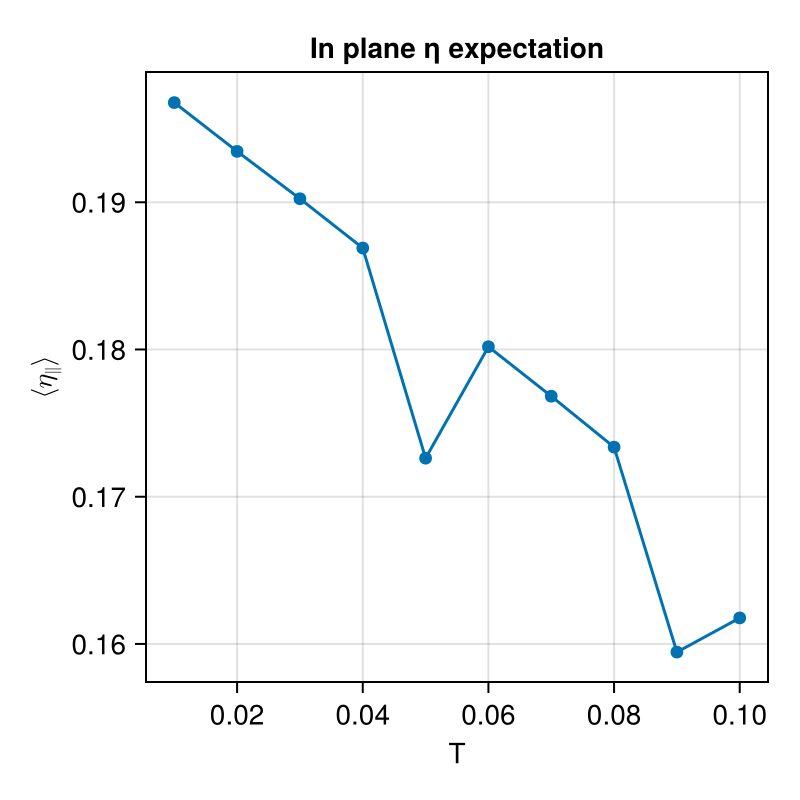

In [10]:
fig = Figure(size=(400, 400))
fig[1,1] = ax = Axis(fig, title="In plane η expectation", xlabel="T", ylabel=L"\langle\eta_\parallel\rangle")
generate_plot!(ax, :T, :ηxy, results.data)
fig

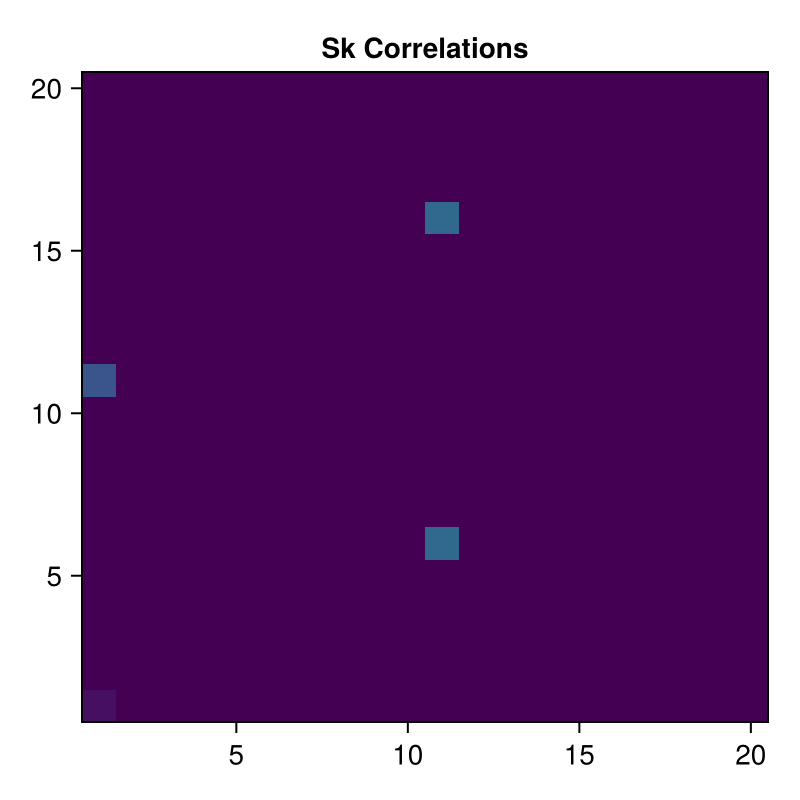

In [16]:
generate_spinks("vbs", 1)